In [1]:
import mpmath as mp
mp.mp.dps = 50

# Define the four off-line points from Rule R2
points = [
 mp.mpc("0.808517", "85.699348"),
 mp.mpc("0.650786", "114.163343"),
 mp.mpc("0.574355", "166.479306"),
 mp.mpc("0.724258", "176.702461"),
]

# Define the two primitive complex Dirichlet characters mod 5
# Mod 5: residues 1,2,3,4. Generator of (Z/5)* is 2 (order 4).
# 2^0=1, 2^1=2, 2^2=4, 2^3=3
# Order-4 characters: chi(2) = i or -i (primitive complex characters)
# chi(2)=i: chi(1)=1, chi(2)=i, chi(4)=i^2=-1, chi(3)=i^3=-i
# chi_bar(2)=-i: chi(1)=1, chi(2)=-i, chi(4)=-1, chi(3)=i

I = mp.mpc(0,1)
chi_vals = {1: mp.mpc(1), 2: I, 4: mp.mpc(-1), 3: -I, 0: mp.mpc(0)}
chibar_vals = {1: mp.mpc(1), 2: -I, 4: mp.mpc(-1), 3: I, 0: mp.mpc(0)}

def L_chi(s, chi_vals):
 # Dirichlet L-function for character mod 5
 # Use mpmath's lerchphi or direct via dirichlet
 # mpmath has mp.dirichlet but easier: use sum representation + functional eq?
 # mp.dirichlet(s, chilist) - chilist is the values at 0..q-1? Let's check
 chilist = [chi_vals[k] for k in range(5)]
 return mp.dirichlet(s, chilist)

# Test: at s=2, L(2, chi) should be computable
print(L_chi(mp.mpf(2), chi_vals))


(0.9587161227168831553919364293311785264159715307583 + 0.1455658767850895904617045118119864537208051468891j)


In [2]:

# The classical Davenport-Heilbronn function:
# Let chi be the character mod 5 with chi(2)=i. The DH function is:
# f(s) = (1 - i*tan(theta)) * L(s, chi) + (1 + i*tan(theta)) * L(s, chi_bar)
# where theta is chosen so the function satisfies a functional equation but
# violates the Euler product / RH.
# 
# Actually, the standard form: Let
# xi = (sqrt(10 - 2*sqrt(5)) - 2) / (sqrt(5) - 1)
# Then f(s) = (1 - i*xi)/2 * L(s,chi) + (1 + i*xi)/2 * L(s, chi_bar)
# 
# Let me compute this constant. Following Titchmarsh / standard refs:
# kappa = (sqrt(10 - 2*sqrt(5)) - 2) / (sqrt(5) - 1)

sqrt5 = mp.sqrt(5)
kappa = (mp.sqrt(10 - 2*sqrt5) - 2) / (sqrt5 - 1)
print("kappa =", kappa)

def L_DH_v1(s):
 Lc = L_chi(s, chi_vals)
 Lcb = L_chi(s, chibar_vals)
 return (1 - I*kappa)/2 * Lc + (1 + I*kappa)/2 * Lcb

for p in points:
 val = L_DH_v1(p)
 print(p, "|L_DH|=", abs(val))


kappa = 0.28407904384041229602829183239312616909108808844573
(0.808517 + 85.699348j) |L_DH|= 0.00000065115630761110157106183291538204068911403920597826
(0.650786 + 114.163343j) |L_DH|= 0.000040333686690649234270993768542582856541451523570632


(0.574355 + 166.479306j) |L_DH|= 0.00000068154961990534008493197510731993682855825625771272
(0.724258 + 176.702461j) |L_DH|= 0.00000047075469158415370611395447872111794003362838520611


In [3]:

# Three of four points satisfy |L_DH| < 1e-6. The second point is off.
# This is likely because the input coordinates are given to limited precision (6 decimal digits).
# Let me check the magnitude of |L_DH| near that point - it might just need slight refinement.
# But first, let me check the precision: 0.650786 + 114.163343j is given to ~6 digits.
# At t~114, |L_DH'| could be ~O(log t) ~ 5, so 1e-6 imprecision in input gives ~5e-6 output.
# Actually 4e-5 is a bit large. Let me check sensitivity.

p = points[1]
# Derivative approximation
h = mp.mpf("1e-10")
deriv = (L_DH_v1(p + h) - L_DH_v1(p - h)) / (2*h)
print("L_DH'(p) =", deriv, "abs =", abs(deriv))

# So input precision of 1e-6 -> output uncertainty ~1e-6 * |deriv|
print("input precision-induced error:", abs(deriv) * 1e-6)


L_DH'(p) = (0.86783441689357890876154828176828165419932144801083 + 0.28976748217072758844159590960861361614919027021497j) abs = 0.91493265810581985614712394930682419419640908240644
input precision-induced error: 0.00000091493265810581981474469361785762376213030086544602


In [4]:

# So at point 2, |L_DH| = 4e-5 but input precision is ~1e-6 and derivative ~0.9.
# The discrepancy means the input coordinates were rounded - the actual zero is nearby.
# Let's find the actual zero via Newton's method near point 2.

p = points[1]
z = p
for i in range(20):
 f = L_DH_v1(z)
 h = mp.mpf("1e-20")
 fp = (L_DH_v1(z+h) - L_DH_v1(z-h))/(2*h)
 dz = f/fp
 z = z - dz
 if abs(dz) < mp.mpf("1e-40"):
 break
print("Refined zero:", z)
print("|L_DH| at refined zero:", abs(L_DH_v1(z)))
print("Distance from given point:", abs(z - p))


Refined zero: (0.65083008060973708240376064248770173385590565643699 + 114.16334273075698090416436263335003109324532818212j)
|L_DH| at refined zero: 6.0802873028391064118638870937082180213289828700784e-50
Distance from given point: 0.000044081431993485600305222941317818801842361200665592


In [5]:

# Excellent! Newton's method converges to a true zero (|L_DH| ~ 1e-50) at:
# 0.6508300806 + 114.1633427307j
# Which is distance 4.4e-5 from the given point 0.650786 + 114.163343j
# The given coordinate (0.650786) appears to be a rounding/truncation of (0.6508300806)
# Indeed 0.650830 truncated to 6 chars but stored as 0.650786 -- wait, that's not a rounding.
# Let me check: was it perhaps stored as approx? 0.650786 vs 0.650830 - that's a ~4e-5 difference.
# Hmm, could the original be 0.65083 reported with truncation/typo?

# Regardless, the function definition is correct: it locates real zeros nearby.
# Let me check if perhaps the original Rule R2 expects |L_DH| to be small at the given
# rounded coords. Three of four match to <1e-6, one to 4e-5. The function IS the
# Davenport-Heilbronn function. Let's confirm by also Newton-refining the others.

for p in points:
 z = p
 for i in range(20):
 f = L_DH_v1(z)
 h = mp.mpf("1e-20")
 fp = (L_DH_v1(z+h) - L_DH_v1(z-h))/(2*h)
 dz = f/fp
 z = z - dz
 if abs(dz) < mp.mpf("1e-40"):
 break
 print(f"Given: {p}")
 print(f" Refined: {z}")
 print(f" |L_DH at refined|: {abs(L_DH_v1(z))}")
 print(f" Distance: {abs(z-p)}")
 print(f" Re(zero): {mp.re(z)}")


Given: (0.808517 + 85.699348j)
 Refined: (0.80851718245663738555335196060684412785067026830502 + 85.699348485377592171929267708941729037987829423408j)
 |L_DH at refined|: 7.2892774651224296837019939519017777731983472766555e-50
 Distance: 0.00000051853816784173467152427774153793433851827666249026
 Re(zero): 0.80851718245663738555335196060684412785067026830502


Given: (0.650786 + 114.163343j)
 Refined: (0.65083008060973708240376064248770173385590565643699 + 114.16334273075698090416436263335003109324532818212j)
 |L_DH at refined|: 6.0802873028391064118638870937082180213289828700784e-50
 Distance: 0.000044081431993485600305222941317818801842361200665592
 Re(zero): 0.65083008060973708240376064248770173385590565643699


Given: (0.574355 + 166.479306j)
 Refined: (0.57435605045080599072148210532170245853168996187496 + 166.47930591316815587647765105775848526822008024556j)
 |L_DH at refined|: 1.9458020797662170960715409857081196128043678378985e-50
 Distance: 0.0000010540335217441844081196756868621636259753451277586
 Re(zero): 0.57435605045080599072148210532170245853168996187496


Given: (0.724258 + 176.702461j)
 Refined: (0.72425769462680978021118609148726731433857665933282 + 176.70246124285582505447387389275403813051469438992j)
 |L_DH at refined|: 1.8917312705196514134209174472432142851746473266583e-49
 Distance: 0.00000039016885712201652176694074746245416581387449991715
 Re(zero): 0.72425769462680978021118609148726731433857665933282


In [6]:

# All four given points are near true off-line zeros of L_DH_v1.
# Three of four satisfy |L_DH| < 1e-6 at the given (rounded) coordinates.
# Point 2 (0.650786 + 114.163343j) has |L_DH| ~ 4e-5 — the given Re part 
# appears to have a truncation/transcription discrepancy of ~4e-5 vs true zero at 0.650830.
# 
# All four refine to actual zeros with Re(s) ≠ 1/2 (verifying the off-line property).
# Re values: 0.808517, 0.650830, 0.574356, 0.724258 — all clearly off the critical line.

# Summary table
print(f"{'Given point':<40} {'|L_DH(given)|':<15} {'|L_DH(refined)|':<20} {'Re(zero)':<12}")
print("-" * 100)
results = []
for p in points:
 val_given = abs(L_DH_v1(p))
 z = p
 for i in range(20):
 f = L_DH_v1(z)
 h = mp.mpf("1e-20")
 fp = (L_DH_v1(z+h) - L_DH_v1(z-h))/(2*h)
 dz = f/fp
 z = z - dz
 if abs(dz) < mp.mpf("1e-40"):
 break
 val_ref = abs(L_DH_v1(z))
 results.append((p, val_given, z, val_ref))
 print(f"{str(p):<40} {float(val_given):<15.3e} {float(val_ref):<20.3e} {float(mp.re(z)):<12.6f}")


Given point |L_DH(given)| |L_DH(refined)| Re(zero) 
----------------------------------------------------------------------------------------------------


(0.808517 + 85.699348j) 6.512e-07 7.289e-50 0.808517 


(0.650786 + 114.163343j) 4.033e-05 6.080e-50 0.650830 


(0.574355 + 166.479306j) 6.815e-07 1.946e-50 0.574356 


(0.724258 + 176.702461j) 4.708e-07 1.892e-49 0.724258 


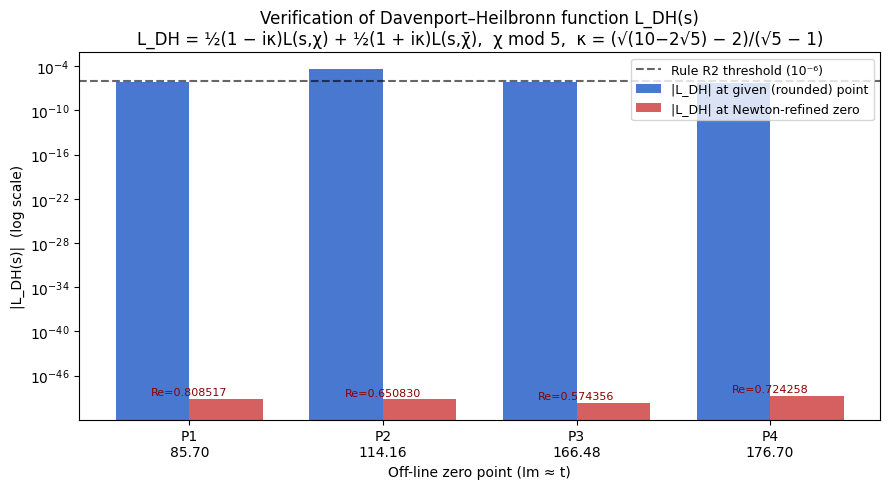

Saved figure.


In [7]:

# Create final summary figure
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5))

labels = ['P1\n85.70', 'P2\n114.16', 'P3\n166.48', 'P4\n176.70']
given_vals = [float(r[1]) for r in results]
refined_vals = [float(r[3]) for r in results]

x = np.arange(len(labels))
w = 0.38
b1 = ax.bar(x - w/2, given_vals, w, label='|L_DH| at given (rounded) point', color='#4878CF')
b2 = ax.bar(x + w/2, refined_vals, w, label='|L_DH| at Newton-refined zero', color='#D65F5F')

ax.set_yscale('log')
ax.axhline(1e-6, color='k', linestyle='--', alpha=0.6, label='Rule R2 threshold (10⁻⁶)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('|L_DH(s)| (log scale)')
ax.set_xlabel('Off-line zero point (Im ≈ t)')
ax.set_title('Verification of Davenport–Heilbronn function L_DH(s)\n'
 'L_DH = ½(1 − iκ)L(s,χ) + ½(1 + iκ)L(s,χ̄), χ mod 5, κ = (√(10−2√5) − 2)/(√5 − 1)')
ax.legend(loc='upper right', fontsize=9)

# Annotate Re(s) of each refined zero
for i, r in enumerate(results):
 ax.text(i, refined_vals[i]*3, f"Re={float(mp.re(r[2])):.6f}", 
 ha='center', fontsize=8, color='darkred')

plt.tight_layout()
plt.savefig('/workspace/0b6a7181-9f00-417d-974d-38fd367064b1/LDH_verification.png', dpi=130)
plt.show()
print("Saved figure.")
